# GBT Regressor — Predicción de Estrés

El objetivo es predecir el nivel de **estrés futuro** en una zona geográfica, agregado por hora y día. Se definen **tres targets** distintos que representan el estrés en diferentes horizontes temporales:
 
| Target | Horizonte |
|---|---|
| `target_stress_t1` | +1 hora |
| `target_stress_t3` | +3 horas |
| `target_stress_t24` | +24 horas |
 
Se entrena **un modelo independiente por target**, todos con la misma arquitectura: **GBTRegressor sobre Spark ML**.

Los datos provienen de un dataset de parquets particionados en `data/aggregated/ex_stress/df_stress_zone_hour_day`. Se filtran filas donde el target o el timestamp sean nulos.
 
La partición es **temporal estricta** (no aleatoria), lo cual es crítico para evitar data leakage en series temporales:
 
```
Train: 70%  →  Val: 15%  →  Test: 15%
```
 
El split se hace por `timestamp_hour`, preservando el orden cronológico. Los bounds (fechas de corte) se guardan en el report JSON.

## Preprocesamiento y pipeline
 
El pipeline de Spark ML tiene las siguientes etapas en orden:
 
### a) Encoding de categóricas
- `StringIndexer` convierte cada columna string a índice numérico (`col__idx`)
- Por defecto **no se aplica OneHotEncoder** (mejor para árboles: evita explosión de memoria y dimensionalidad)
- Si se activa `--one-hot-cats`, se añade un `OneHotEncoder` tras el indexer
### b) Ensamblado de features
- `VectorAssembler` une todas las columnas numéricas + las categóricas codificadas en un único vector `features`
- `handleInvalid="keep"` en todas las etapas → los nulos se gestionan sin romper el pipeline
### c) Modelo
- `GBTRegressor` con `labelCol="label"` y `featuresCol="features"`

## Hiperparámetros
 
**Defaults conservadores** (orientados a entornos con recursos limitados):
 
| Parámetro | Default | Descripción |
|---|---|---|
| `maxIter` | 50 | Nº de árboles (iteraciones de boosting) |
| `maxDepth` | 4 | Profundidad máxima por árbol |
| `stepSize` | 0.1 | Learning rate |
| `subsamplingRate` | 0.8 | Fracción de datos por iteración (bagging) |
| `maxBins` | 16 | Bins para discretizar features continuas |
| `minInstancesPerNode` | 2 | Mínimo de muestras por hoja |
| `featureSubsetStrategy` | `sqrt` | Nº de features por split (estilo Random Forest) |

## Búsqueda de hiperparámetros (tuning)
 
Cuando se activa `--tune`, se realiza un **grid search manual sobre validación temporal**:
 
- Grid por defecto: `maxIter ∈ {30,50,70}`, `maxDepth ∈ {3,4,5}`, `stepSize ∈ {0.05,0.1}`, `subsamplingRate ∈ {0.7,0.8}`
- Se muestrea una fracción de train/val para acelerar (`tune_train_sample_frac`, `tune_val_sample_frac`)
- Métrica de selección configurable: `rmse` (default), `mae`, o `r2`
- El mejor trial se guarda en `gbt_stress_spark_tuning_report.json` y todos los trials en `gbt_stress_spark_tuning_trials.csv`

## Protocolo de entrenamiento y evaluación
 
```
[Train] → fit pipeline → predice en Train, Val, Test  (detectar overfitting)
           ↓
[Train + Val] → refit con mejores hiperparámetros → predice en Test  (modelo final)
```
 
- El **modelo base** (solo train) sirve para medir overfitting mirando los gaps entre splits.
- El **refit train+val** es el modelo final que se guarda y se usa para evaluar en test.
- Opcionalmente, `--fit-all-data` entrena un tercer modelo sobre train+val+test para despliegue (sus métricas son in-sample y no válidas para medir generalización).

**Métricas calculadas:** `MAE`, `RMSE`, `R²`
 
**Overfit gaps calculados automáticamente:**
- `val_rmse - train_rmse`
- `test_rmse - train_rmse`
- `train_r2 - val_r2`
- `train_r2 - test_r2`

## A) Análisis numérico

**1. Desempeño y Generalización**

A partir de las métricas obtenidas para los tres horizontes temporales (+1h, +3h y +24h), podemos extraer tres conclusiones clave que validan la robustez de los modelos:

- **Ausencia de Overfitting (Excelente Generalización):** En los tres targets, la diferencia de rendimiento entre los datos de entrenamiento (Train) y los datos no vistos (Val y Test Final) es mínima. Por ejemplo, en el target a +1h, la caída del $R^2$ es de apenas un 0.0087 (de 0.7698 a 0.7611), y el RMSE crece menos de 0.05 puntos. Esto demuestra que la estrategia de partición temporal y la regularización del modelo (control de profundidad y _subsampling_) han funcionado perfectamente, evitando que el árbol memorice la serie.

- **Alto Poder Predictivo General:** Los tres modelos explican una proporción muy alta de la varianza del estrés. Mantener un $R^2$ en la franja del 0.73 - 0.76 en datos de test completamente futuros es un resultado excepcional para series temporales. Además, el error medio absoluto (MAE) se mantiene estable alrededor de 0.48 - 0.52 puntos, lo que significa que la desviación real de nuestras predicciones es muy contenida.

- **Comportamiento Temporal y Estacionalidad:** Lo habitual es que el rendimiento se degrade linealmente a medida que aumenta el horizonte de predicción. Sin embargo, observamos un patrón muy interesante: el modelo a +3h ($R^2$ 0.7380) rinde ligeramente peor que el modelo a +24h ($R^2$ 0.7551). Esto tiene todo el sentido del negocio: predecir el estrés exactamente a la misma hora del día siguiente (+24h) es más fácil debido a la fuerte **estacionalidad diaria** (patrones cíclicos de la ciudad), mientras que un horizonte de +3h cruza diferentes bloques horarios que pueden ser más volátiles e impredecibles (ej. pasar de un bloque valle a plena hora punta).

In [2]:
import json
import pandas as pd
import os

base_path = "../outputs/ejercicio2/gbt/"
targets = ["t1", "t3", "t24"]

results = []

for target in targets:
    report_path = os.path.join(base_path, target, "gbt_stress_spark_report.json")
    
    with open(report_path, "r") as f:
        data = json.load(f)
        
        metrics = data.get("metrics", {})
        train_fit = metrics.get("train_fit", {})
        refit = metrics.get("train_val_refit", {})
        
        # Extraemos Train y Val del primer fit (para evaluar el overfit puro)
        train_metrics = train_fit.get("train_seen", {})
        val_metrics = train_fit.get("val_unseen", {})
        
        # Extraemos Test del modelo final reentrenado (Train + Val)
        test_metrics = refit.get("test_unseen", {})
        
        row = {
            "Target": f"+{target.replace('t', '')}h",
            "Train R²": round(train_metrics.get("r2", 0), 4),
            "Val R²": round(val_metrics.get("r2", 0), 4),
            "Test Final R²": round(test_metrics.get("r2", 0), 4),
            "Train RMSE": round(train_metrics.get("rmse", 0), 4),
            "Val RMSE": round(val_metrics.get("rmse", 0), 4),
            "Test Final RMSE": round(test_metrics.get("rmse", 0), 4),
            "Train MAE": round(train_metrics.get("mae", 0), 4),
            "Val MAE": round(val_metrics.get("mae", 0), 4),
            "Test Final MAE": round(test_metrics.get("mae", 0), 4)
        }
        results.append(row)


df_metrics = pd.DataFrame(results)
display(df_metrics)

,Target,Train R²,Val R²,Test Final R²,Train RMSE,Val RMSE,Test Final RMSE,Train MAE,Val MAE,Test Final MAE
0,+1h,0.7698,0.7597,0.7611,0.7678,0.7984,0.8116,0.4596,0.4780,0.4860
1,+3h,0.7537,0.7431,0.7380,0.7942,0.8255,0.8501,0.4921,0.5080,0.5246
2,+24h,0.7653,0.7573,0.7551,0.7752,0.8026,0.8217,0.4693,0.4833,0.4976


**2. Overfit gaps**

Los resultados demuestran de forma contundente que ninguno de los tres modelos sufre de overfitting. Las métricas de degradación entre los datos vistos en entrenamiento y los datos estrictamente futuros (Test) son mínimas y excepcionalmente saludables:

- **Degradación casi nula:** Al evaluar el modelo final en el conjunto de Test, el error (RMSE) apenas sube unos 0.04 puntos de media, y la capacidad explicativa ($R^2$) cae menos de un 1% (aprox. 0.009) en todos los horizontes temporales.

- **Consistencia total:** Los gaps son prácticamente idénticos tanto en el modelo base (Train vs Val) como en el modelo final a producción (TrainVal vs Test). El comportamiento de los modelos es muy predecible, sin sorpresas al enfrentarse a datos nuevos.

- **Validación de la arquitectura:** Mantener unos gaps tan estrechos confirma que las decisiones de diseño y los hiperparámetros aplicados (como limitar el `maxDepth` y usar un `subsamplingRate` de 0.8) han funcionado a la perfección, logrando que el árbol aprenda los patrones reales de la ciudad y no memorice el ruido del pasado.

In [4]:

results_gaps = []

for target in targets:
    report_path = os.path.join(base_path, target, "gbt_stress_spark_report.json")
    
    with open(report_path, "r") as f:
        data = json.load(f)
        
        metrics = data.get("metrics", {})
        
        # Extraemos los gaps del primer entrenamiento (Train -> Val)
        train_fit_gaps = metrics.get("train_fit", {}).get("overfit_gaps", {})
        
        # Extraemos los gaps del modelo final reentrenado (Train+Val -> Test)
        refit_gaps = metrics.get("train_val_refit", {}).get("overfit_gaps", {})
        
        row = {
            "Target": f"+{target.replace('t', '')}h",
            "Val - Train RMSE (Base)": round(train_fit_gaps.get("val_minus_train_rmse", 0), 4),
            "Train - Val R² (Base)": round(train_fit_gaps.get("train_minus_val_r2", 0), 4),
            "Test - TrainVal RMSE (Final)": round(refit_gaps.get("test_minus_train_val_rmse", 0), 4),
            "TrainVal - Test R² (Final)": round(refit_gaps.get("train_val_minus_test_r2", 0), 4)
        }
        results_gaps.append(row)


df_gaps = pd.DataFrame(results_gaps)
display(df_gaps)

,Target,Val - Train RMSE (Base),Train - Val R² (Base),Test - TrainVal RMSE (Final),TrainVal - Test R² (Final)
0,+1h,0.0306,0.0101,0.0411,0.0087
1,+3h,0.0313,0.0106,0.0441,0.0101
2,+24h,0.0274,0.0080,0.0422,0.0093


**3. Análisis del tuning**

Revisando los 3 mejores trials (Top 3) resultantes del grid search para cada horizonte temporal, extraemos dos conclusiones muy claras que refuerzan la solidez del proyecto:

- **Unanimidad en los parámetros ganadores:** El espacio de búsqueda ha convergido exactamente hacia la misma configuración óptima para los tres horizontes temporales (+1h, +3h y +24h). El modelo ganador (Trial 8) siempre utiliza **70 iteraciones, profundidad máxima de 5 y un step size de 0.1**. Esto indica que la naturaleza del problema base (predecir estrés) mantiene una estructura matemática similar independientemente de la distancia temporal.

- **Alta estabilidad y robustez:** El _tuning_ es muy estable. En los tres targets, el orden de los mejores modelos es idéntico (Trials 8, 7 y 1) y la diferencia de error (RMSE) entre el primero y el tercero es mínima (apenas ~0.02 puntos). Esto demuestra que el modelo es robusto frente a ligeras variaciones de hiperparámetros; no hemos ganado "por casualidad" en un pico de suerte del algoritmo, sino que hemos encontrado una zona óptima y estable de aprendizaje.

- **Aprovechamiento de la complejidad:** Los modelos tienden a elegir los parámetros más complejos del grid propuesto (máxima profundidad y número de árboles evaluados). Como en el apartado anterior demostramos que no hay overfitting, esto es una gran noticia: significa que nuestros datos tienen suficiente señal y volumen para alimentar un modelo profundo sin que este empiece a memorizar ruido.

In [6]:
dfs = []

for target in targets:
    csv_path = os.path.join(base_path, target, "gbt_stress_spark_tuning_trials.csv")
    
    df = pd.read_csv(csv_path)
    
    # Filtramos y ordenamos por val_rmse de mejor a peor
    df_top = df.sort_values(by='val_rmse', ascending=True).head(3).copy()
    
    # Seleccionamos las columnas que nos interesan para el análisis
    df_top = df_top[['trial', 'gbt_max_iter', 'gbt_max_depth', 'gbt_step_size', 'val_rmse']]
    
    # Añadimos la columna del Target al principio
    df_top.insert(0, 'Target', f"+{target.replace('t', '')}h")
    
    dfs.append(df_top)

# Juntamos todo y renombramos columnas para que quede presentable
df_tuning = pd.concat(dfs, ignore_index=True)
df_tuning.columns = ['Target', 'Trial', 'Max Iter', 'Max Depth', 'Step Size', 'Val RMSE']
display(df_tuning)

,Target,Trial,Max Iter,Max Depth,Step Size,Val RMSE
0,+1h,8,70,5,0.1,0.798501
1,+1h,7,70,4,0.1,0.809365
2,+1h,1,50,4,0.1,0.820875
3,+3h,8,70,5,0.1,0.823337
4,+3h,7,70,4,0.1,0.838629
5,+3h,1,50,4,0.1,0.848859
6,+24h,8,70,5,0.1,0.803563
7,+24h,7,70,4,0.1,0.813509
8,+24h,1,50,4,0.1,0.821250


**4. Feature Importance: Evolución Temporal**

Al comparar las 10 variables más predictivas en los tres horizontes (+1h, +3h y +24h), observamos cómo el modelo adapta inteligentemente su estrategia según la distancia de la predicción:

- **La volatilidad de precios:** La variable `z_price_variability` domina absolutamente en los tres modelos (pesos entre 0.17 y 0.23). Esto confirma una hipótesis de negocio clave: las fluctuaciones en el precio (dinamismo de tarifas) son el mejor indicador temprano del nivel de estrés y saturación de una zona.

- **El efecto "Espejo Diario" (+1h y +24h):** Los modelos a +1h y +24h se comportan de forma sorprendentemente similar. Le dan muchísimo peso al estado inmediato de la zona (`n_trips` y `avg_price`). Esto ocurre porque predecir a +1h es una continuación directa del presente, y predecir a +24h se apoya en la fortísima estacionalidad diaria (lo que pasa hoy a las 10:00 es muy similar a lo que pasará mañana a las 10:00).

- **El "Cambio de Régimen" (+3h):** El horizonte a +3h es el más complejo porque implica saltar a un bloque horario distinto (ej. pasar de un valle de tarde a la hora punta nocturna). Aquí, el modelo penaliza la información actual (`n_trips` cae de 0.15 a 0.04) y delega todo el peso a las variables temporales (`hour` sube de 0.09 a 0.17, y `hour_block_3h` dobla su peso) y a las tendencias suavizadas (`roll_24h_price_variability` salta de 0.03 a 0.10). El modelo "sabe" que la foto actual ya no sirve dentro de 3 horas, por lo que se guía por la hora del día y la inercia diaria.

- **El stress_score como ancla:** La métrica base de estrés se mantiene estable aportando un valor constante (0.04 - 0.06) en todos los horizontes, demostrando que su formulación inicial era robusta.

In [8]:
df_all = pd.DataFrame()

for target in targets:
    csv_path = os.path.join(base_path, target, "gbt_stress_spark_feature_importance.csv")
    
    df = pd.read_csv(csv_path)
    
    col_name = f"+{target.replace('t', '')}h"
    df = df[['feature', 'importance']].rename(columns={'importance': col_name})
    
    if df_all.empty:
        df_all = df
    else:
        # Outer join para no perder features que puedan faltar en algún modelo
        df_all = pd.merge(df_all, df, on='feature', how='outer')


# Rellenamos nulos con 0 por si alguna feature no se usó en un target
df_all = df_all.fillna(0)

# Ordenamos por el peso a corto plazo (+1h)
df_all = df_all.sort_values(by='+1h', ascending=False)
    
# Redondeamos a 4 decimales para que la tabla sea legible
cols_to_round = [c for c in df_all.columns if c != 'feature']
df_all[cols_to_round] = df_all[cols_to_round].round(4)

display(df_all.head(10))

,feature,+1h,+3h,+24h
32,z_price_variability,0.2105,0.1719,0.2254
18,n_trips,0.1499,0.0468,0.1479
5,hour,0.0973,0.1714,0.0523
25,roll_24h_trips,0.0699,0.1098,0.0631
28,stress_score,0.0591,0.0447,0.0676
0,avg_price,0.0528,0.0032,0.0728
6,hour_block_3h,0.0455,0.0869,0.0315
12,lag_24h_avg_price,0.0353,0.0160,0.0258
13,lag_24h_price_variability,0.0338,0.0087,0.0391
24,roll_24h_price_variability,0.0316,0.1044,0.0291


## B) Análisis gráfico

**1. Barchart de feature importances**

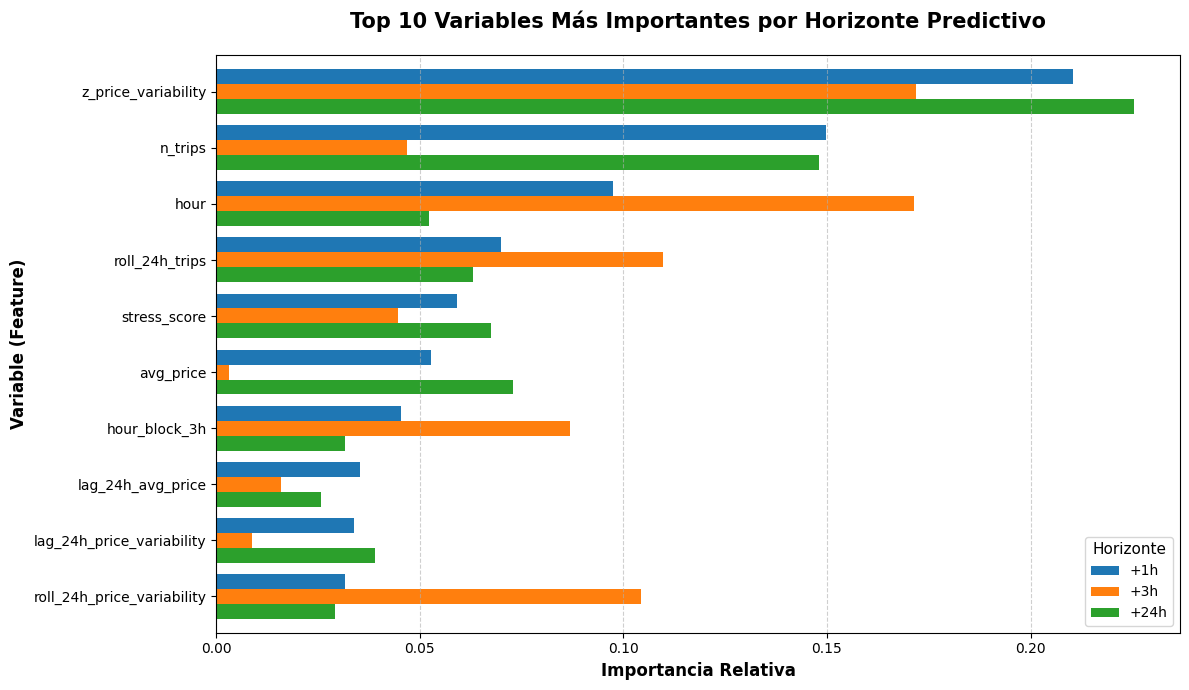

In [10]:
import matplotlib.pyplot as plt

# Configuración de estilo básico
plt.style.use('default')

df_all = pd.DataFrame()

# Cargar y cruzar datos
for target in targets:
    csv_path = os.path.join(base_path, target, "gbt_stress_spark_feature_importance.csv")
    
    df = pd.read_csv(csv_path)
    col_name = f"+{target.replace('t', '')}h"
    df = df[['feature', 'importance']].rename(columns={'importance': col_name})
    if df_all.empty:
        df_all = df
    else:
        df_all = pd.merge(df_all, df, on='feature', how='outer')

# Procesar y dibujar
df_all = df_all.fillna(0)
# Seleccionamos el Top 10 basado en el corto plazo
df_top = df_all.sort_values(by='+1h', ascending=False).head(10)

# Ponemos la feature como índice para que plot.barh lo use en el eje Y
df_plot = df_top.set_index('feature')

# Crear la figura
fig, ax = plt.subplots(figsize=(12, 7))

colores = ['#1f77b4', '#ff7f0e', '#2ca02c'] 
df_plot.plot(kind='barh', width=0.8, ax=ax, color=colores)

# Invertir eje Y para que la más importante salga arriba del todo
ax.invert_yaxis() 

ax.set_title('Top 10 Variables Más Importantes por Horizonte Predictivo', fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Importancia Relativa', fontsize=12, fontweight='bold')
ax.set_ylabel('Variable (Feature)', fontsize=12, fontweight='bold')
ax.legend(title='Horizonte', title_fontsize='11', fontsize='10')
ax.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**2. Heatmap de métricas**

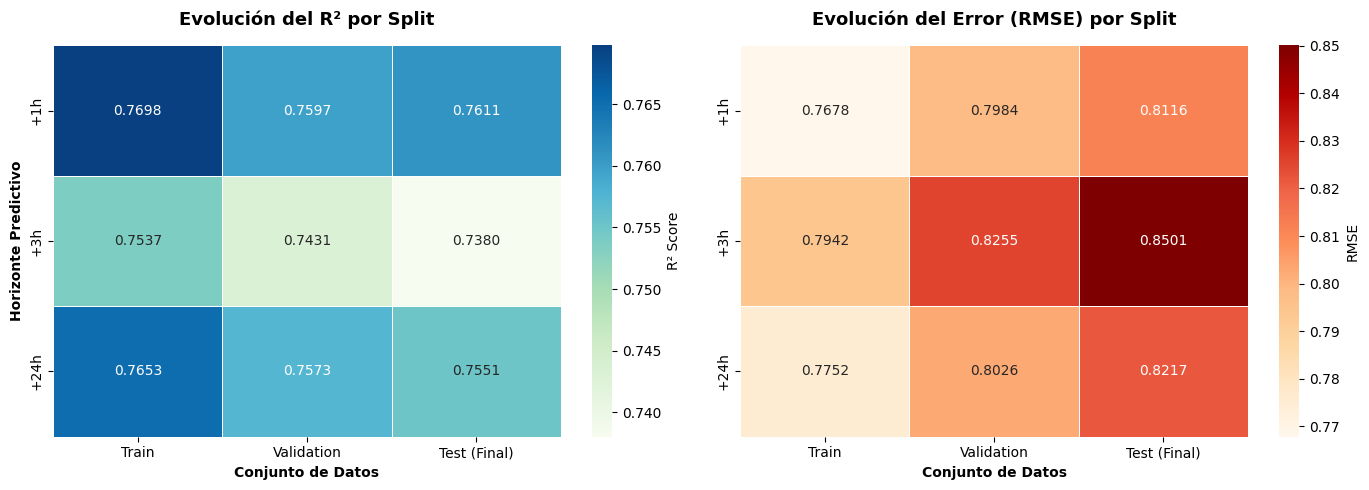

In [11]:
import seaborn as sns

# Separar las métricas en dos DataFrames distintos para los heatmaps
df_r2 = df_metrics.set_index('Target')[['Train R²', 'Val R²', 'Test Final R²']]
df_rmse = df_metrics.set_index('Target')[['Train RMSE', 'Val RMSE', 'Test Final RMSE']]

# Renombrar columnas para que quede más limpio en el gráfico
df_r2.columns = ['Train', 'Validation', 'Test (Final)']
df_rmse.columns = ['Train', 'Validation', 'Test (Final)']

# Crear la figura con dos subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap R² (Tonos azules/verdes: más oscuro es mejor)
sns.heatmap(df_r2, annot=True, fmt=".4f", cmap="GnBu", ax=axes[0], 
            cbar_kws={'label': 'R² Score'}, linewidths=.5)
axes[0].set_title('Evolución del R² por Split', pad=15, fontweight='bold', fontsize=13)
axes[0].set_ylabel('Horizonte Predictivo', fontweight='bold')
axes[0].set_xlabel('Conjunto de Datos', fontweight='bold')

# Heatmap RMSE (Tonos rojos/naranjas: más oscuro es peor/más error)
sns.heatmap(df_rmse, annot=True, fmt=".4f", cmap="OrRd", ax=axes[1], 
            cbar_kws={'label': 'RMSE'}, linewidths=.5)
axes[1].set_title('Evolución del Error (RMSE) por Split', pad=15, fontweight='bold', fontsize=13)
axes[1].set_ylabel('') # Ocultamos el eje Y porque es el mismo que el de la izquierda
axes[1].set_xlabel('Conjunto de Datos', fontweight='bold')


plt.tight_layout()
plt.show()

**3. Scatter plot: predicciones vs. valores reales**

El modelo reproduce adecuadamente la tendencia general entre valores reales y predichos, con una concentración de densidad alineada con la diagonal ideal. No obstante, se observa una dispersión considerable, lo que indica errores no despreciables incluso en regiones densas.

Se aprecia un sesgo sistemático leve hacia la media: los valores altos de estrés tienden a subestimarse, mientras que los valores bajos se sobreestiman. Además, el modelo parece presentar una cierta saturación en los valores predichos, dificultando la captura de picos extremos.

El rendimiento es más robusto en el rango de valores bajo-medio, donde se concentra la mayoría de las observaciones.

26/04/20 22:36:38 WARN DataSource: [COLUMN_ALREADY_EXISTS] The column `month` already exists. Choose another name or rename the existing column. SQLSTATE: 42711


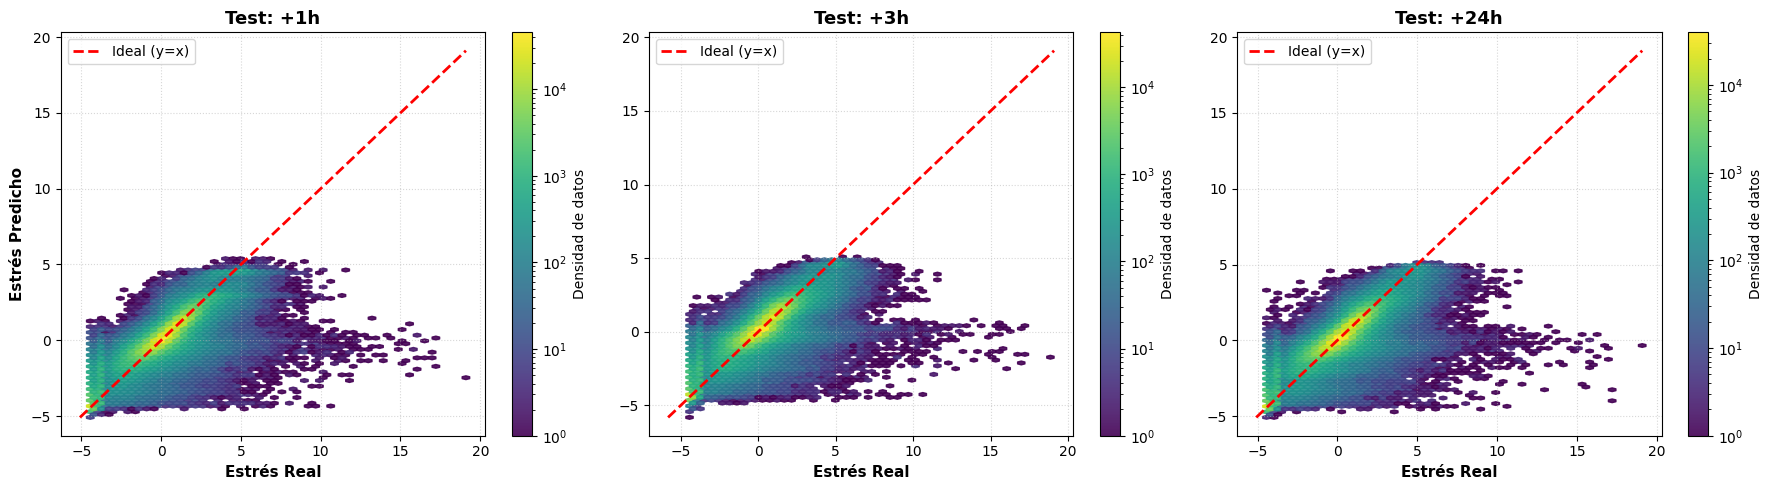

In [15]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.ml import PipelineModel

# Iniciar SparkSession
spark = SparkSession.builder \
    .appName("Analisis_Test_GBT") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

# Cargar el dataset original completo
data_path = "../data/aggregated/ex_stress/df_stress_zone_hour_day"
df_completo = spark.read.parquet(data_path)

# Configuración de la figura
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
targets = ["t1", "t3", "t24"]
horizontes = ["+1h", "+3h", "+24h"]

base_model_path = "../outputs/ejercicio2/gbt/"

for i, target in enumerate(targets):

    # Filtrar por fecha para obtener solo la partición de Test dinámicamente
    report_path = os.path.join(base_model_path, target, "gbt_stress_spark_report.json")
    
    with open(report_path, "r") as f:
        data = json.load(f)
        bounds = data["split_params"]["bounds"]
    
    test_start_date = bounds['test_start']
    df_test_base = df_completo.filter(F.col("timestamp_hour") >= F.lit(test_start_date))

    target_col = f"target_stress_{target}"
    df_test = df_test_base.filter(F.col(target_col).isNotNull())
    
    model_path = os.path.join(base_model_path, target, "gbt_stress_spark_model")
    
    try:
        # Cargar el modelo entrenado
        modelo = PipelineModel.load(model_path)
        
        # Hacer predicciones
        predicciones = modelo.transform(df_test)
        
        # Traernos a Pandas SOLO las dos columnas que necesitamos para no saturar la memoria RAM
        df_plot = predicciones.select(target_col, "prediction").toPandas()
        
        y_real = df_plot[target_col]
        y_pred = df_plot["prediction"]
        
        
        hb = axes[i].hexbin(y_real, y_pred, gridsize=50, cmap='viridis', mincnt=1, bins='log', alpha=0.9)
        
        # Dibujar la línea diagonal ideal (y = x)
        min_val = min(y_real.min(), y_pred.min())
        max_val = max(y_real.max(), y_pred.max())
        axes[i].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal (y=x)')
        
        axes[i].set_title(f'Test: {horizontes[i]}', fontsize=13, fontweight='bold')
        axes[i].set_xlabel('Estrés Real', fontsize=11, fontweight='bold')
        if i == 0:
            axes[i].set_ylabel('Estrés Predicho', fontsize=11, fontweight='bold')
            
        axes[i].legend(loc='upper left')
        axes[i].grid(True, linestyle=':', alpha=0.5)
        
        # Añadir barra de color a cada gráfico
        cb = fig.colorbar(hb, ax=axes[i])
        cb.set_label('Densidad de datos')
        
    except Exception as e:
        print(f"Error procesando target {target}: {e}")

plt.tight_layout()
plt.show()

spark.stop()

**4. Distribución de residuos** 

La distribución de residuos en los tres horizontes temporales muestra un comportamiento globalmente adecuado, con una clara concentración en torno a cero, lo que indica ausencia de sesgo global significativo.

La forma leptocúrtica de las distribuciones revela que la mayoría de las predicciones presentan errores pequeños, especialmente en los rangos más frecuentes del fenómeno. Sin embargo, la presencia de colas relativamente largas indica que existen errores no despreciables en ciertos casos, particularmente en situaciones menos habituales.

Se observa una ligera asimetría hacia residuos positivos, lo que sugiere una tendencia del modelo a subestimar valores altos de estrés, en línea con el comportamiento conservador observado previamente.

Asimismo, se aprecia una leve degradación del rendimiento a medida que aumenta el horizonte temporal, reflejada en una mayor dispersión de los residuos. Este comportamiento es consistente con el incremento de incertidumbre inherente a predicciones a más largo plazo.

Finalmente, los resultados sugieren una posible heterocedasticidad, donde la varianza del error aumenta en escenarios más extremos.

26/04/20 22:54:21 WARN DataSource: [COLUMN_ALREADY_EXISTS] The column `month` already exists. Choose another name or rename the existing column. SQLSTATE: 42711


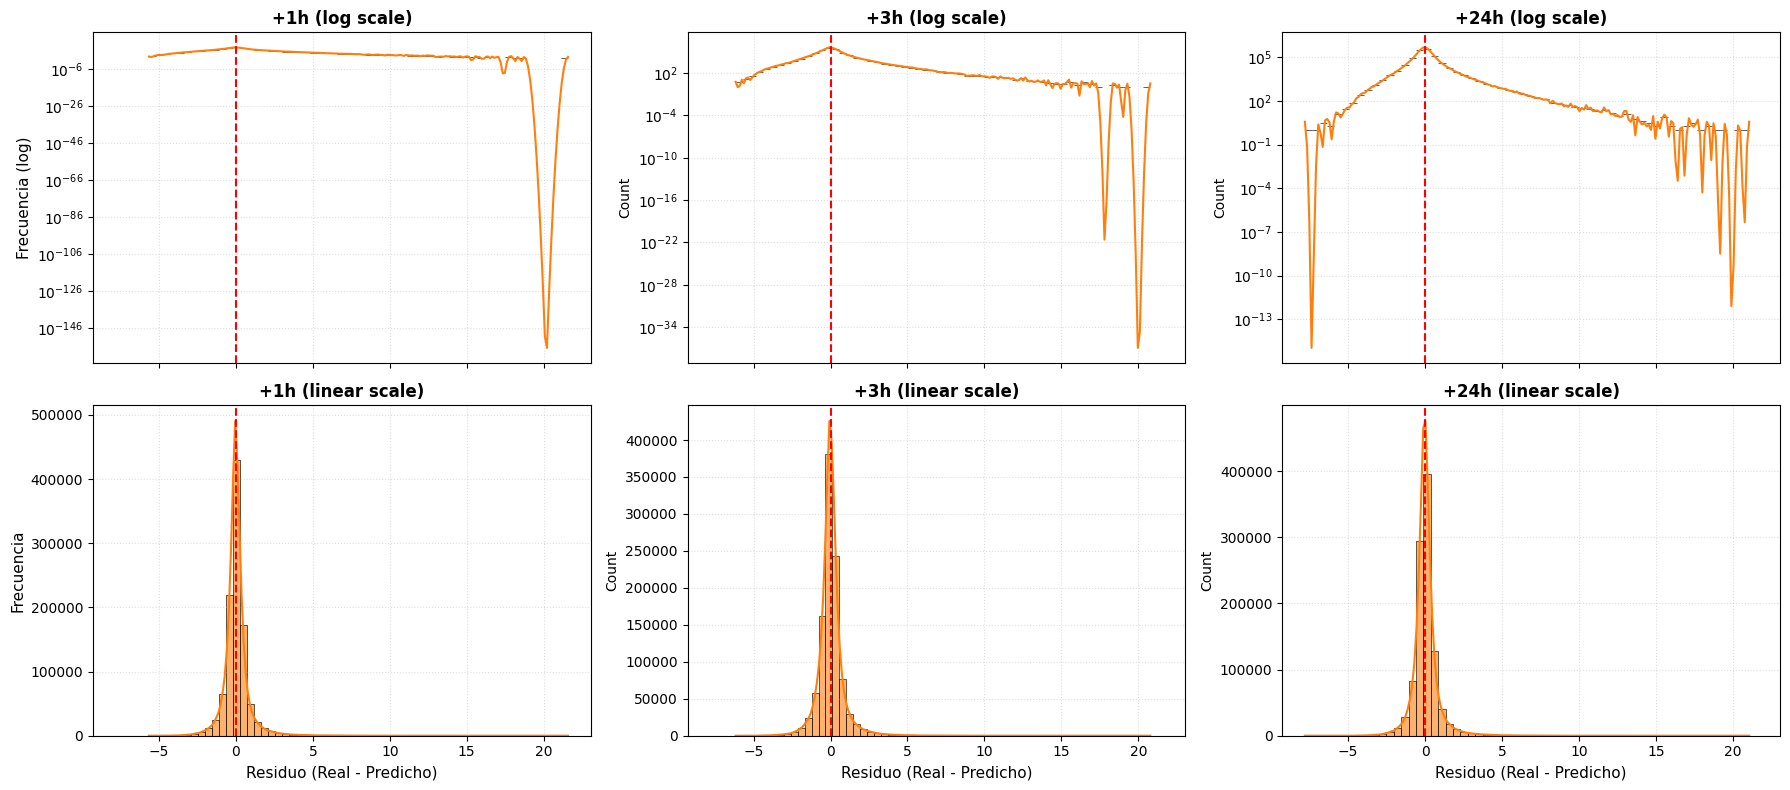

In [20]:
spark = SparkSession.builder.appName("Analisis_Test_GBT").getOrCreate()

data_path = "../data/aggregated/ex_stress/df_stress_zone_hour_day"
df_completo = spark.read.parquet(data_path)

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)

targets = ["t1", "t3", "t24"]
horizontes = ["+1h", "+3h", "+24h"]

for i, target in enumerate(targets):

    test_start_date = "2025-07-20 19:00:00"
    df_test_base = df_completo.filter(F.col("timestamp_hour") >= F.lit(test_start_date))

    target_col = f"target_stress_{target}"
    df_test = df_test_base.filter(F.col(target_col).isNotNull())

    model_path = os.path.join(base_model_path, target, "gbt_stress_spark_model")

    try:
        modelo = PipelineModel.load(model_path)
        predicciones = modelo.transform(df_test)

        df_plot = predicciones.select(target_col, "prediction").toPandas()
        df_plot['residual'] = df_plot[target_col] - df_plot['prediction']

        # -------- FILA 0: escala log --------
        ax_log = axes[0, i]

        sns.histplot(
            df_plot['residual'],
            bins=60,
            kde=True,
            ax=ax_log,
            color='#ff7f0e',
            edgecolor='black',
            alpha=0.6,
            log_scale=(False, True)  # 👈 clave
        )

        ax_log.axvline(0, color='red', linestyle='--', linewidth=1.5)
        ax_log.set_title(f'{horizontes[i]} (log scale)', fontsize=12, fontweight='bold')
        ax_log.grid(True, linestyle=':', alpha=0.4)


        # -------- FILA 1: escala normal --------
        ax_lin = axes[1, i]

        sns.histplot(
            df_plot['residual'],
            bins=60,
            kde=True,
            ax=ax_lin,
            color='#ff7f0e',
            edgecolor='black',
            alpha=0.6
        )

        ax_lin.axvline(0, color='red', linestyle='--', linewidth=1.5)
        ax_lin.set_title(f'{horizontes[i]} (linear scale)', fontsize=12, fontweight='bold')
        ax_lin.grid(True, linestyle=':', alpha=0.4)


        # -------- etiquetas --------
        if i == 0:
            ax_log.set_ylabel('Frecuencia (log)', fontsize=11)
            ax_lin.set_ylabel('Frecuencia', fontsize=11)

        ax_lin.set_xlabel('Residuo (Real - Predicho)', fontsize=11)

    except Exception as e:
        print(f"Error procesando target {target}: {e}")

plt.tight_layout()
plt.show()

spark.stop()

**5. Residuos vs. tiempo**

El modelo demuestra una robustez estructural notable al mantener la media de los residuos cercana a cero durante todo el periodo de test. Esta estabilidad confirma la ausencia de data drift, garantizando que las predicciones mantienen su validez técnica sin sufrir una degradación inmediata tras el entrenamiento inicial.

Se han detectado oscilaciones cíclicas en la tendencia de los errores, lo que revela que el modelo no captura con total exactitud la estacionalidad horaria de la ciudad. Estas fluctuaciones sugieren que el sistema tiende a ser ligeramente optimista o pesimista en franjas específicas, marcando una oportunidad de mejora futura.

La precisión es inversamente proporcional al horizonte temporal, mostrando un control casi total en las predicciones a corto plazo frente a una mayor volatilidad en las de largo plazo. El ensanchamiento de las ondas de error en horizontes lejanos es una consecuencia natural y esperada de la incertidumbre acumulada.

En conclusión, el sistema es plenamente apto para su despliegue operativo al presentar fallos predecibles y una varianza constante en el tiempo. La fiabilidad general es alta, siempre que se considere el aumento del margen de error en las planificaciones que superan el ciclo diario de veinticuatro horas.

26/04/20 22:58:29 WARN DataSource: [COLUMN_ALREADY_EXISTS] The column `month` already exists. Choose another name or rename the existing column. SQLSTATE: 42711


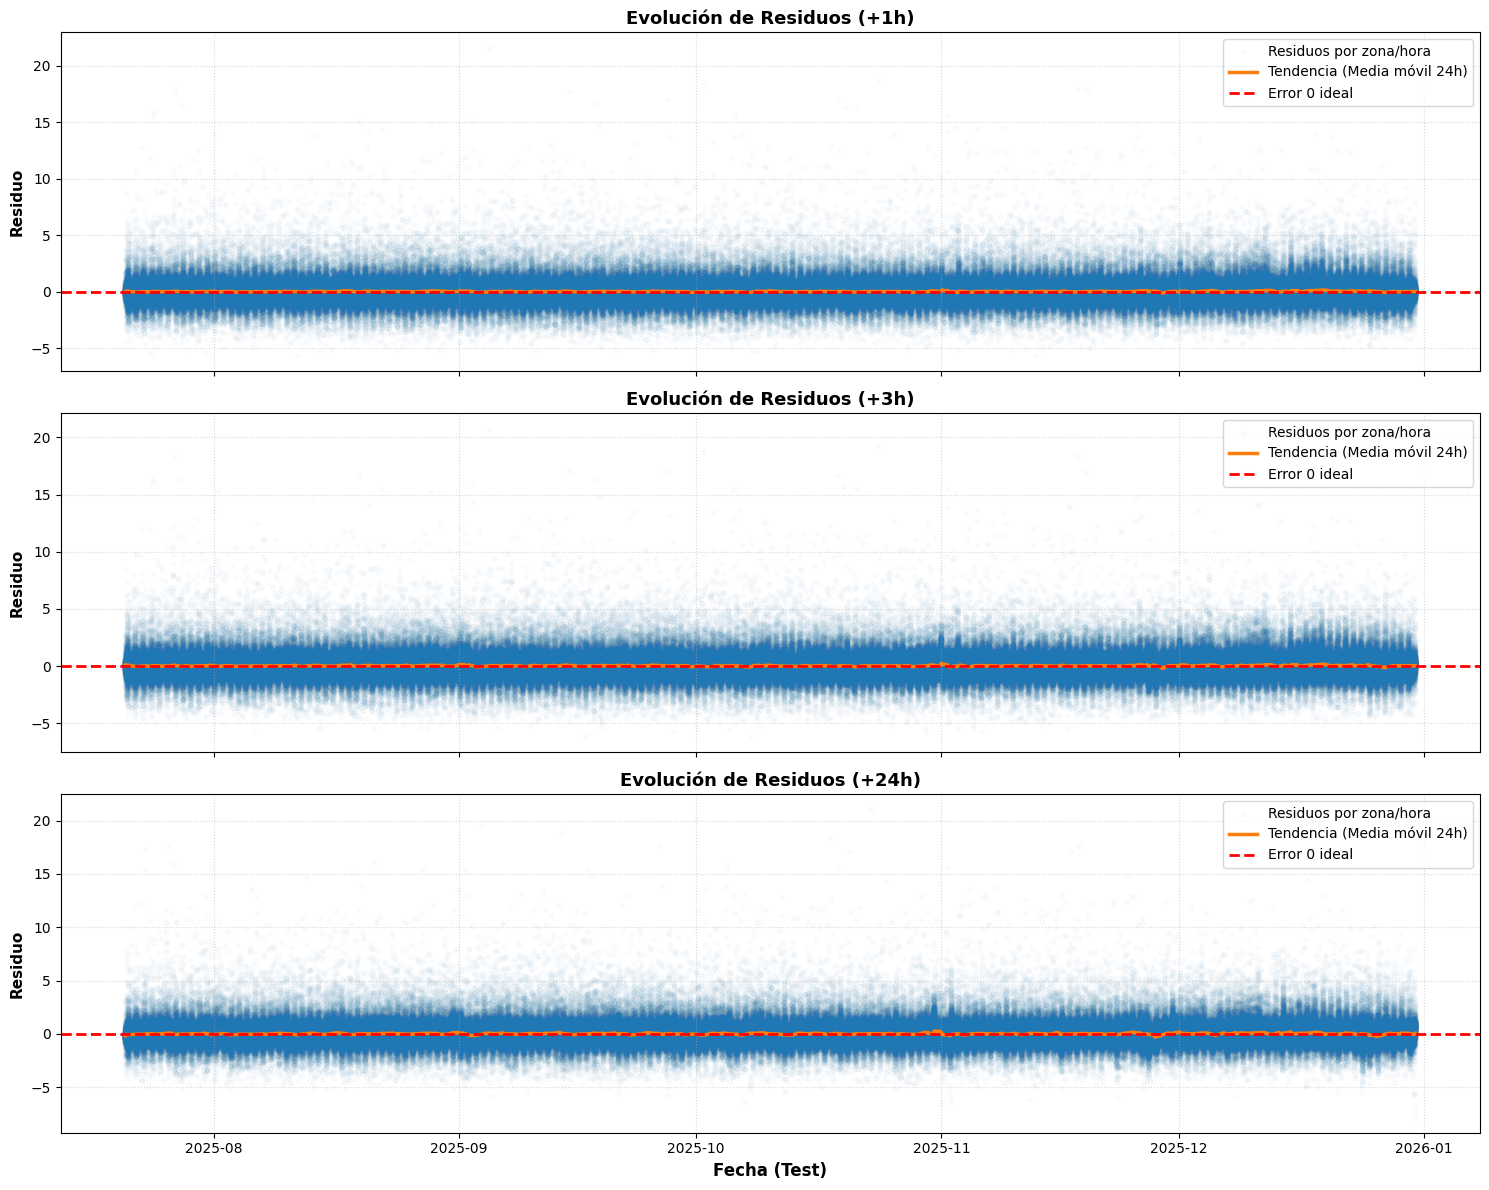

In [21]:
spark = SparkSession.builder.appName("Analisis_Test_GBT").getOrCreate()

data_path = "../data/aggregated/ex_stress/df_stress_zone_hour_day"
df_completo = spark.read.parquet(data_path)

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
targets = ["t1", "t3", "t24"]
horizontes = ["+1h", "+3h", "+24h"]
base_model_path = "../outputs/ejercicio2/gbt/"

for i, target in enumerate(targets):
    
    test_start_date = "2025-07-20 19:00:00" 
    df_test_base = df_completo.filter(F.col("timestamp_hour") >= F.lit(test_start_date))

    target_col = f"target_stress_{target}"
    df_test = df_test_base.filter(F.col(target_col).isNotNull())
    
    model_path = os.path.join(base_model_path, target, "gbt_stress_spark_model")
    
    try:
        # Cargar modelo y predecir
        modelo = PipelineModel.load(model_path)
        predicciones = modelo.transform(df_test)
        
        df_plot = predicciones.select("timestamp_hour", target_col, "prediction").toPandas()
        
        # Preparar datos de tiempo
        df_plot['timestamp_hour'] = pd.to_datetime(df_plot['timestamp_hour'])
        df_plot = df_plot.sort_values('timestamp_hour')
        df_plot['residual'] = df_plot[target_col] - df_plot['prediction']
        
        # Dibujar puntos individuales con opacidad bajísima para ver densidad
        axes[i].scatter(df_plot['timestamp_hour'], df_plot['residual'], 
                        alpha=0.02, color='#1f77b4', s=10, label='Residuos por zona/hora')
        
        # Calcular residuo medio de toda la ciudad por hora
        df_mean = df_plot.groupby('timestamp_hour')['residual'].mean().reset_index()
        
        # Aplicar media móvil de 24h para ver la tendencia clara
        df_mean['rolling_res'] = df_mean['residual'].rolling(window=24, min_periods=1).mean()
        
        axes[i].plot(df_mean['timestamp_hour'], df_mean['rolling_res'], 
                     color='#ff7f0e', linewidth=2.5, label='Tendencia (Media móvil 24h)')
        
        # Línea ideal 0
        axes[i].axhline(0, color='red', linestyle='--', linewidth=2, label='Error 0 ideal')
        
        axes[i].set_title(f'Evolución de Residuos ({horizontes[i]})', fontsize=13, fontweight='bold')
        axes[i].set_ylabel('Residuo', fontsize=11, fontweight='bold')
        axes[i].legend(loc='upper right')
        axes[i].grid(True, linestyle=':', alpha=0.5)
        
    except Exception as e:
        print(f"Error procesando target {target}: {e}")

axes[2].set_xlabel('Fecha (Test)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

spark.stop()

**6. Curva de tuning**

La curva de optimización muestra una exploración efectiva del espacio de hiperparámetros, logrando identificar el "Mejor Trial" (marcado en rojo) con el menor RMSE de validación. Se observa una tendencia de mejora respecto a los intentos iniciales, lo que justifica el proceso de tuning para maximizar la capacidad de generalización del modelo GBT. Este ajuste fino permite encontrar el equilibrio óptimo entre la profundidad de los árboles y la tasa de aprendizaje, evitando el sobreajuste.

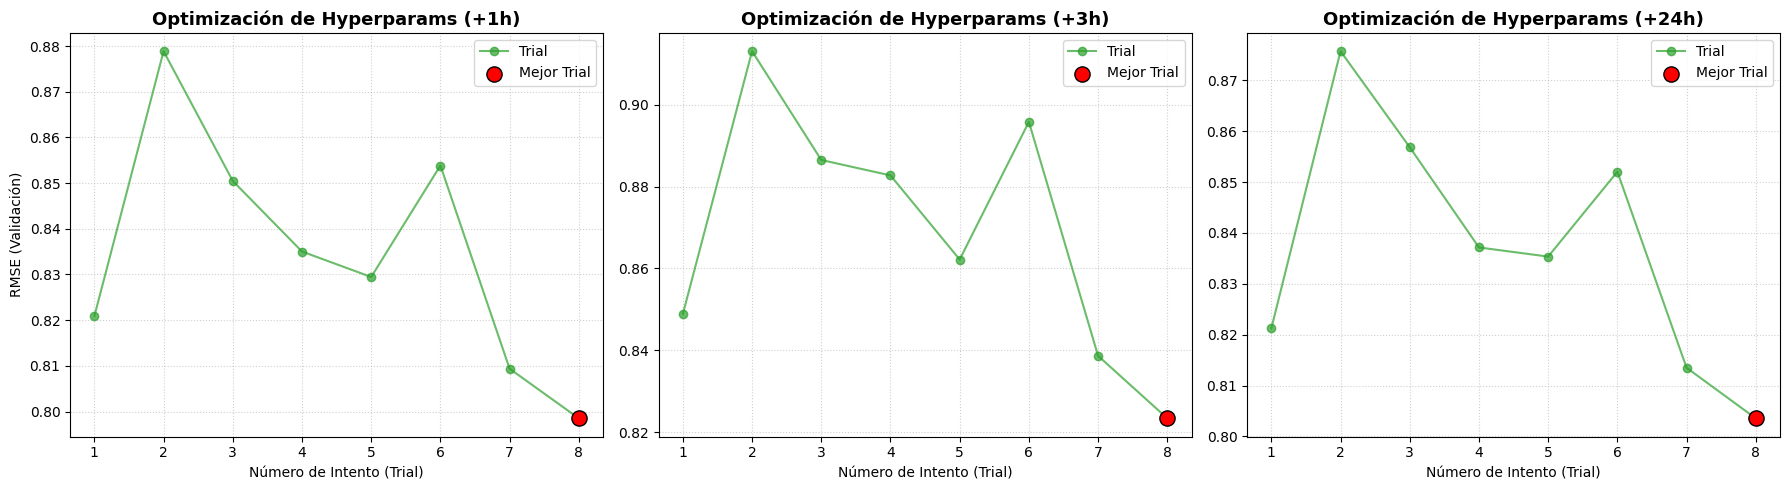

In [25]:
base_model_path = "../outputs/ejercicio2/gbt/"
targets = ["t1", "t3", "t24"]
horizontes = ["+1h", "+3h", "+24h"]

fig6, axes6 = plt.subplots(1, 3, figsize=(18, 5))

for i, target in enumerate(targets):
    trials_path = os.path.join(base_model_path, target, "gbt_stress_spark_tuning_trials.csv")
    
    if os.path.exists(trials_path):
        df_trials = pd.read_csv(trials_path)
        
        # Dibujar la evolución de todos los trials
        axes6[i].plot(df_trials['trial'], df_trials['val_rmse'], 
                      marker='o', linestyle='-', color='#2ca02c', alpha=0.7, label='Trial')
        
        # Resaltar el mejor trial (el de menor RMSE)
        best_idx = df_trials['val_rmse'].idxmin()
        best_trial = df_trials.loc[best_idx]
        
        axes6[i].scatter(best_trial['trial'], best_trial['val_rmse'], 
                         color='red', s=120, zorder=5, label='Mejor Trial', edgecolors='black')
        
        axes6[i].set_title(f'Optimización de Hyperparams ({horizontes[i]})', fontsize=13, fontweight='bold')
        axes6[i].set_xlabel('Número de Intento (Trial)')
        if i == 0:
            axes6[i].set_ylabel('RMSE (Validación)')
        axes6[i].grid(True, linestyle=':', alpha=0.6)
        axes6[i].legend()
    else:
        axes6[i].text(0.5, 0.5, f'Archivo no encontrado:\n{target}', ha='center')

plt.tight_layout()
plt.show()

**7. Comparativa de RMSE por horizonte temporal**

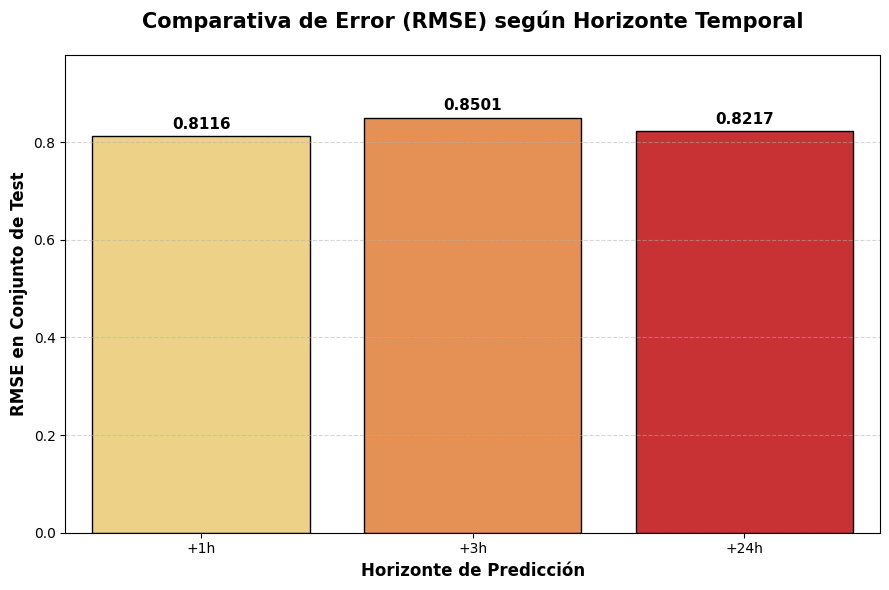

In [27]:
rmse_test_values = []

for target in targets:
    report_path = os.path.join(base_model_path, target, "gbt_stress_spark_report.json")
    if os.path.exists(report_path):
        with open(report_path, "r") as f:
            report = json.load(f)
            # Extraemos el RMSE del conjunto de test
            val = report['metrics']['train_val_refit']['test_unseen']['rmse']
            rmse_test_values.append(val)
    else:
        rmse_test_values.append(0)

plt.figure(figsize=(9, 6))
# Usamos un degradado de color para enfatizar el aumento de dificultad
colors = sns.color_palette("YlOrRd", len(horizontes))
barplot = sns.barplot(
    x=horizontes,
    y=rmse_test_values,
    hue=horizontes,
    palette=colors,
    edgecolor='black',
    legend=False
)

plt.title('Comparativa de Error (RMSE) según Horizonte Temporal', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('RMSE en Conjunto de Test', fontsize=12, fontweight='bold')
plt.xlabel('Horizonte de Predicción', fontsize=12, fontweight='bold')

# Añadir los valores exactos encima de las barras
for i, v in enumerate(rmse_test_values):
    plt.text(i, v + (max(rmse_test_values)*0.01), f"{v:.4f}", 
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.ylim(0, max(rmse_test_values) * 1.15) # Espacio para las etiquetas
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()